Clusterability and mixability looked at the global distribution of cells in PC space. EMD loss compared to baseline models similarly looked at the accuracy of the predicted global distribution. Here, we like pairwise distances between single-cells in the full TF activity space. We use euclidean distance as our distance metric.  

We have two expectations:
1. Distances within a cell type + stimulation condition are smaller than distances within a cell type across stimulations. 
2. Distances within a cell type + stimulation condition are smaller than a null distribution of distances between a random subset of cells of the same size. 

For each cell type, we will compared the predicted values of a given stimulation  to the actual values of the opposite stimulation. 

We will also need to set up baselines which use the actual data of the same condition as the predicted, to assess that our expectations are in fact met and how closely the predicted values compare.  

In [20]:
import os
import itertools
import json

from tqdm import tqdm 

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from scipy import stats
from statsmodels.stats.multitest import multipletests
from cliffs_delta import cliffs_delta

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import seaborn as sns

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import calculate_pairwise_distances, get_upper_triangle, quantify_cluster_distance

sys.path.insert(1, '../.')
from Kang_utils import get_prediction, rev_stim


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Params:

In [5]:
distance_metric = 'euclidean'

Load data:

In [6]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [8]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

# test_cells = trainer.X_test.index.tolist()
# train_cells_all = trainer.X_train.index.tolist()
# test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())

#### Get the predictions and concordance:

As described in Notebook 06E, for each cell type, we get the counterfactual from all in-distribution or within a cell type ("opposite").

In [13]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

tf_predicted_res = {}
for counterfactual_type in counterfactual_types:
    tf_adata_predicted = get_prediction(mod = mod, 
                                        tf_adata = tf_adata, 
                                        counterfactual_type = counterfactual_type, 
                                        cf_map = cf_map, 
                                        train_cells_all = train_cells_all, 
                                        test_conds = test_conds
                                        )
    tf_predicted_res[counterfactual_type] = tf_adata_predicted

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


#### Expectation 1: Within stimulation distances < across stimulation distances

In [14]:
def expectation_1_distances(predicted_df, actual_df, ctrl_df):
    
    across_actual = calculate_pairwise_distances(df1 = actual_df, 
                                                df2 = ctrl_df, 
                                                distance_metric = distance_metric, 
                                                axis = 0, 
                                                invert_corr = True).values.flatten()
    across_predicted = calculate_pairwise_distances(df1 = predicted_df, 
                                                df2 = ctrl_df, 
                                                distance_metric = distance_metric, 
                                                axis = 0, 
                                                invert_corr = True).values.flatten()

    within_actual = get_upper_triangle(calculate_pairwise_distances(df1 = actual_df, 
                                                                    df2 = None, 
                                                                    distance_metric = distance_metric, 
                                                                    axis = 0, 
                                                                    invert_corr = True
                                                                   )
                                      )

    within_predicted = get_upper_triangle(calculate_pairwise_distances(df1 = predicted_df, 
                                                                       df2 = None,
                                                                       distance_metric = distance_metric, 
                                                                       axis = 0, 
                                                                       invert_corr = True
                                                                      )
                                      )

#     within_ctrl = get_upper_triangle(calculate_pairwise_distances(df1 = ctrl_df, 
#                                                                   df2 = None,
#                                                                   distance_metric = distance_metric, 
#                                                                   axis = 0, 
#                                                                   invert_corr = True
#                                                                  )
#                                      )
    
    e1_res = {'Across Actual': across_actual, 
              'Within Actual': within_actual, 
             'Across Predicted': across_predicted, 
             'Within Predicted': within_predicted
             } 
            # 'Within Ctrl': within_ctrl}
    
    return e1_res

In [15]:
# e1_res_all = {}
# for counterfactual_type, tf_adata_predicted in tf_predicted_res.items():
#     e1_res_conds = {}
#     for cond in tqdm(test_conds):
#         stim, cell_type = cond.split('^')
#         ctrl_cond = '^'.join([rev_stim[stim], cell_type])

#         predicted_df = tf_adata_predicted[tf_adata_predicted.obs.condition == cond, :].to_df()
#         actual_df = tf_adata[tf_adata.obs.condition == cond, :].to_df()
#         ctrl_df = tf_adata[tf_adata.obs.condition == ctrl_cond].to_df()

#         e1_res = expectation_1_distances(predicted_df, actual_df, ctrl_df)
#         e1_res_conds[cond] = e1_res
#     e1_res_all[counterfactual_type] = e1_res_conds
# io.write_pickled_object(e1_res_all, os.path.join(data_path, 'interim',author + '_pairwise_distances_e1.pickle'))
e1_res_all = io.read_pickled_object(os.path.join(data_path, 'interim',author + '_pairwise_distances_e1.pickl'))

100%|███████████████████████████████████████████████| 4/4 [00:03<00:00,  1.30it/s]


Visualization: We expect the across to be greater than the within for both actual and predicted. We test this with a one-sided MWU. We also expec the within actual and within predicted to be equal. We test this with a two-sided MWU. We quantiyf differences with Cohen's D. Statistics are run on all data. For reasonable computational time, violin plots are visualized on a subset of 1e3 distances and stats are calculated on a subset of 1e4 distances when those numbes are surpassed.

In [50]:
viz_subset_size = int(1e3)
stats_subset_size = int(1e4)

''

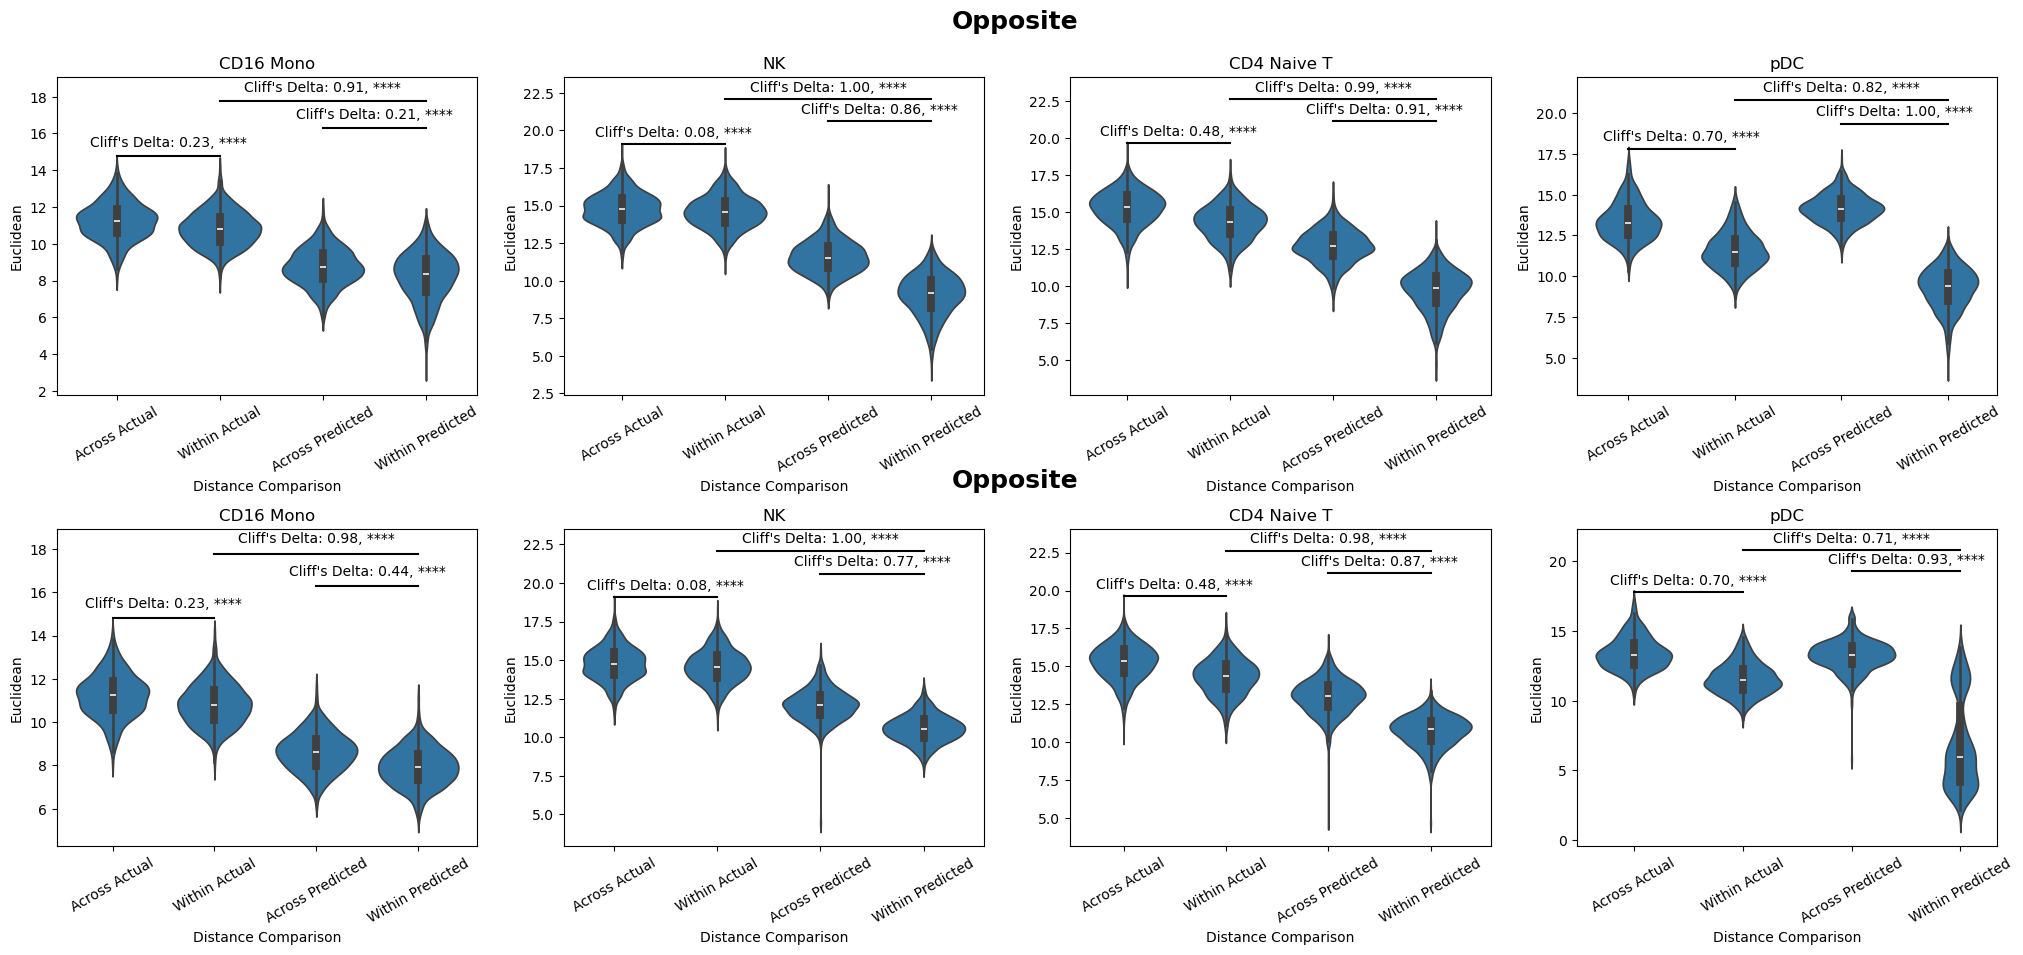

In [53]:
ncols = len(e1_res_conds)
nrows = len(e1_res_all)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols * 5.1, nrows*5.1))

counterfactual_type_title = {'in_distribution': 'In Disribution', 'opposite': 'Opposite'}
title_coords = [0.92, 0.47]

for i, (counter_factual_type, e1_res_conds) in enumerate(e1_res_all.items()):
    for j, (cond, e1_res) in enumerate(e1_res_conds.items()):
        # get statistics
        
        e1_res_stats = {}
        for k,v in e1_res.items():
            np.random.seed(seed)
            if len(v) > stats_subset_size:
                np.random.seed(seed)
                v = np.random.choice(v, stats_subset_size, replace = False)
            e1_res_stats[k] = v
        
        
        pvals = []
        effect_size = []
        for comp, alternative in alternatives.items():
            _, pval = stats.mannwhitneyu(e1_res_stats[comp[0]], e1_res_stats[comp[1]], alternative = alternative)
            pvals.append(pval)
            effect_size.append(cliffs_delta(e1_res_stats[comp[0]], e1_res_stats[comp[1]])[0])
        #             effect_size.append(cohen_d(e1_res_stats[comp[0]], e1_res_stats[comp[1]]))
        _, fdr, _, _ = multipletests(pvals, method='fdr_bh')

        # subset for reasonable visualization
        e1_res_viz = {}
        for k,v in e1_res.items():
            np.random.seed(seed)
            if len(v) > viz_subset_size:
                np.random.seed(seed)
                v = np.random.choice(v, viz_subset_size, replace = False)
            e1_res_viz[k] = v

        # plot violins
        categories = []
        violin_data = []
        for category, values in e1_res_viz.items():
            categories.extend([category] * len(values))
            violin_data.extend(values)

        sns.violinplot(x=categories, y=violin_data, ax = ax[i,j])

        # annotate statistics
        xtick_positions = [tick.get_position()[0] for tick in ax[i,j].get_xticklabels()]
        x_pos_dict = {label: pos for label, pos in zip(e1_res.keys(), range(len(e1_res)))}
        annotation_y_offset = 1.5
        annotation_y_offset_2 = 0.5
        max_y = max([max(values) for values in e1_res_viz.values()]) + annotation_y_offset_2

        for idx, ((group1, group2), p_value, effect) in enumerate(zip(comparisons, fdr, effect_size)):

            significance = "N.S."
            if p_value <= 1e-4:
                significance = "****"
            elif p_value <= 0.001:
                significance = "***"
            elif p_value <= 0.01:
                significance = "**"
            elif p_value <= 0.1:
                significance = "*"

            x1 = x_pos_dict[group1]
            x2 = x_pos_dict[group2]
            x_mid = (x1 + x2) / 2

            y_pos = max_y + (idx * annotation_y_offset)
            ax[i,j].plot([x1, x2], [y_pos, y_pos], color='black', lw=1.5)
            annotation_text = "Cliff's Delta: {:.2f}, ".format(effect) + significance #'Cohen'f"Cohen's d={effect:.2f}"
            ax[i,j].text(x_mid, y_pos + annotation_y_offset_2, annotation_text, ha='center', color='black', fontsize=10)
            #     ax[i,j].text(x_mid, y_pos + 0.3, f"Cohen's d={effect:.2f}", ha='center', color='black', fontsize=10)


        ymin, ymax = ax[i,j].get_ylim()
        ax[i,j].set_ylim(ymin, ymax + annotation_y_offset_2)
        ax[i,j].set_xlabel("Distance Comparison")
        ax[i,j].set_ylabel(distance_metric.capitalize())
        ax[i,j].set_title(cond.split('^')[1])
        ax[i,j].xaxis.set_major_locator(FixedLocator(ax[i,j].get_xticks()))
        ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), rotation=30, ha='center')
        
    fig.text(0.5, title_coords[i], 
             counterfactual_type_title[counterfactual_type], 
             ha='center', va='center', fontsize=18, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.9])
;


#### Expectation 2: Within stimulation distances < random distances

For test conditions with greater than 2000 cells (occurs for the in-distribution predictions), we randomly subset to 2000 cells for computation time

In [74]:
comp_subset_size = int(2e3)

In [54]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)


In [12]:
# for counterfactual_type, tf_adata_predicted in tf_predicted_res.items():
#     print(counterfactual_type)
#     tf_adata_predicted.obs['batch'] = 'predicted'
#     tf_adata_actual = tf_adata.copy()
#     tf_adata_actual.obs['batch'] = 'actual'
#     tf_adata_all = sc.concat([tf_adata_predicted, tf_adata_actual])
#     tf_adata_all.obs['condition'] = tf_adata_all.obs['batch'].astype(str) + '&' + tf_adata_all.obs['condition'].astype(str)

#     label = 'condition'
#     comparison_combination_subset = []
#     for comp in itertools.combinations_with_replacement(tf_adata_all.obs['condition'].unique(), 2):
#         if comp[0].split('&')[1] and comp[1].split('&')[1] in test_conds:
#             if comp[0] == comp[1]:
#                 comparison_combination_subset.append(comp)
    
#     # subset for reasonable computation time
#     included_conds = list(set(itertools.chain.from_iterable(comparison_combination_subset)))
#     vc = tf_adata_all.obs.condition.value_counts().loc[included_conds]
#     drop_cells = []
#     for ic in vc[vc > comp_subset_size].index.tolist():
#         all_cells = tf_adata_all.obs[tf_adata_all.obs.condition == ic].index.tolist()
#         np.random.seed(seed)
#         drop_cells += list(np.random.choice(all_cells, size = vc.loc[ic] - comp_subset_size, replace = False))
#     tf_adata_all = tf_adata_all[~tf_adata_all.obs_names.isin(drop_cells)]

#     predicted_cells = tf_adata_all.obs[tf_adata_all.obs.batch == 'predicted'].index.tolist() 



#     distances_df = quantify_cluster_distance(tf_adata = tf_adata_all,
#                                      label = 'condition', 
#                                      include_self = True,
#                                      comparison_combination_subset = comparison_combination_subset,
#                                      alternative = 'less',
#                                      exclude_null_cells = predicted_cells, 
#                                      distance_metric = distance_metric,
#                                      n_cores = min(len(comparison_combination_subset), n_cores),
#                                      seed = seed,
#                                      n_perm = 1000,  

#                                      comparison_subset = None,
#                                      label_subset = None,
#                                      feature_subset = None,
#                                      normal = True,
#                                      use_pcs = False,
#                                      rank = None 
#                          )
#     distances_df.to_csv(os.path.join(data_path, 'interim', author + '_' + counterfactual_type + '_null_distances.csv'))
distances_res = {}
for counterfactual_type, tf_adata_predicted in tf_predicted_res.items():
    distances_df = pd.read_csv(os.path.join(data_path, 'interim', author + '_' + counterfactual_type + '_null_distances.csv'), 
                          index_col = 0)
    distances_df = distances_df.reset_index(drop = False, inplace = False).rename(columns = {'index': 'temp'})
    distances_df[['data_type', 'test condition']] = distances_df.temp.str.split('-', expand = True)[0].str.split('&', expand = True)
    distances_df.drop(columns = ['temp'], inplace = True)
    distances_df.sort_values(by = ['test condition', 'data_type'], inplace = True)
    distances_res[counterfactual_type] = distances_df
    

Visualize the results:

In [111]:
fdr_thresh = 0.1

/tmp/ipykernel_958462/2818971262.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels([': '.join(xlabel.get_text().split(': ')[1].split('^')) for xlabel in ax[i].get_xticklabels()],
/tmp/ipykernel_958462/2818971262.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels([': '.join(xlabel.get_text().split(': ')[1].split('^')) for xlabel in ax[i].get_xticklabels()],


''

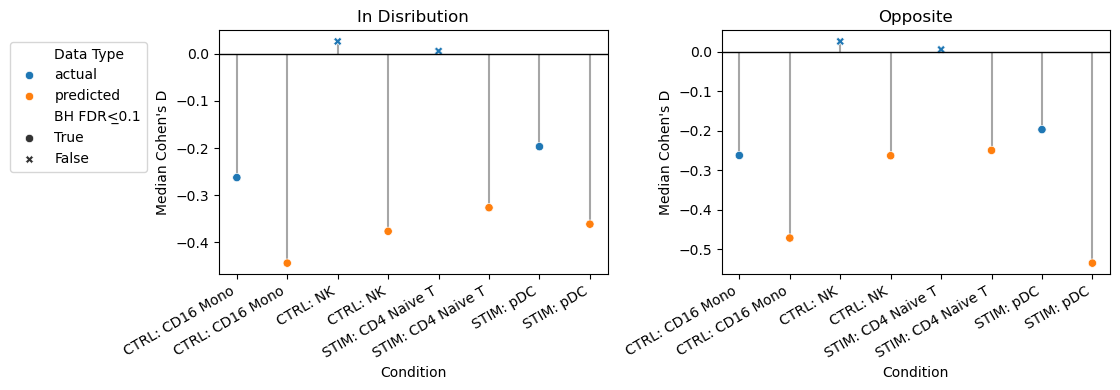

In [122]:
ncols = len(distances_res)
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols *5.1, 4))

cf_map = {'in_distribution': 'In Disribution', 'opposite': 'Opposite'}

for i, (counterfactual_type, distances_df) in enumerate(distances_res.items()):
    viz_df = distances_df.copy()
    viz_df['x'] = viz_df.data_type + ': ' + viz_df['test condition']
    viz_df['significance'] = pd.Categorical(viz_df.BH_FDR <= fdr_thresh, 
                                            ordered = True, 
                                            categories = [True, False])


    sns.scatterplot(data = viz_df, y = 'median_cd', x = 'x', hue = 'data_type',
                    style = 'significance', ax = ax[i])
    if i == 0:
        handles, labels = ax[i].get_legend_handles_labels()
    ax[i].legend().set_visible(False)

    # make lollipop
    ax[i].axhline(0, color='black', linewidth=1)
    ax[i].vlines(x=viz_df.x, ymin=0, ymax=viz_df.median_cd, color='gray', alpha=0.7, zorder=0)


    ax[i].set_xticklabels([': '.join(xlabel.get_text().split(': ')[1].split('^')) for xlabel in ax[i].get_xticklabels()], 
                         rotation = 30, ha = 'right')
    ax[i].set_xlabel('Condition')
    ax[i].set_ylabel("Median Cohen's D")
    ax[i].set_title(cf_map[counterfactual_type])

labels = ['Data Type', 'actual', 'predicted', 'BH FDR<\u0332{:.1f}'.format(fdr_thresh), 'True', 'False']
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(-0.1, 0.9))
fig.tight_layout()
;